# Single Step Predictions

The following notebook creates and evalutes models a single step into the future. Models are trained on 24 hours of Soil Moisture Data, and then make a prediction for one hour of soil moisture 24 hours in the future.

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive
#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

#import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=Warning)

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [ ]:

import argparse
import numpy as np
import pandas as pd
import tensorflow as tf

import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import load_model

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)


Thu Aug 17 01:39:23 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P0    24W / 300W |      0MiB / 16384MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
# Mounting Drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### Data Cleansing, Normalization and Split

The following section reads in the data, vectorizes wind and time, and creates a treaining, validation and testing data frame for each station using only the overlapping time indexes.


In [ ]:
%cd /content/drive/My Drive/TX_DATA/BestData

/content/drive/My Drive/TX_DATA/BestData


In [ ]:
#Read In Data
dfs = {}
for index in range(0, 6):
  df = pd.read_csv('Station' + str(index + 1) + '-Simulated-cleaned-merged-data.csv', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df

In [ ]:
# Vectorize wind
for station, df in dfs.items():
  wv = df.pop('Windspeed')
  wd_rad = df.pop('Winddirection')*np.pi / 180
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

In [ ]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)
  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
  dfs[station] = df

In [ ]:
#Use only overlapping indexes
index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)
index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)

In [ ]:
for key in dfs.keys():
  dfs[key] = dfs[key].loc[index_int]


In [ ]:
for key, df in dfs.items():
  print(key, df.shape)


Station1 (55028, 20)
Station2 (55028, 20)
Station3 (55028, 20)
Station4 (55028, 20)
Station5 (55028, 20)
Station6 (55028, 20)


### Window and Batch Generation Functions

The section below define functions for creating windows and batches for time series analysis as well as functions to plot them. The data is also scaled.

In [ ]:
#Definitions
TARGET_COL = "SWC_50"
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.2
WINDOW_SIZE = 24*10
SHIFT_AMT = 24*7

In [ ]:
def split_and_scale(df, target_col=TARGET_COL, train_split = TRAIN_SPLIT, val_split = VAL_SPLIT):
  print(df.columns)
  target_idx = df.columns.get_loc(target_col)
  scaler = MinMaxScaler(feature_range=(-0.5, 0.5))
  train_set = df[ : int(len(df) * train_split)].values
  val_set = df[int(len(df) * train_split) : int(len(df) * (train_split + val_split))].values
  test_set = df[int(len(df) * (train_split + val_split)) :].values

  train_set = scaler.fit_transform(train_set)
  val_set = scaler.transform(val_set)
  test_set = scaler.transform(test_set)

  return (train_set, val_set, test_set, target_idx)


In [ ]:
def generate_windows(data, window_size=24, shift=24, target_idx=0):
    labels = data[:, target_idx]

    X = []
    y = []
    for i in range(len(data) - window_size - shift):
        # get window based on input width
        window = data[i : i + window_size]

        # keep track of label associated with current window
        window_label = labels[i + window_size + shift]

        X.append(window)
        y.append(window_label)

    # in new dataset, each element is a data window, and window label is single value
    return np.array(X), np.array(y)


# given data and its labels, divide the data into batches of size batch_size
def generate_batches(X, y, batch_size=32):
    # divides data into batches, drops any remainder batches smaller than specified batch size.
    # allows models to run with any batch size
    tf_dataset = tf.data.Dataset.from_tensor_slices((X, y))
    tf_dataset = tf_dataset.repeat().batch(batch_size=batch_size, drop_remainder=True)

    # tf_dataset repeats indefinitely, need to compute number of step updates to complete 1 epoch
    steps_per_epoch = len(X) // batch_size

    return (tf_dataset, steps_per_epoch)




In [ ]:
def preprocess_data(df):
    # data cleaning and feature engineering
    train_set, val_set, test_set, target_idx = split_and_scale(df)


    # create window data for each dataset
    X_train, y_train = generate_windows(train_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_val, y_val = generate_windows(val_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_test, y_test = generate_windows(test_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

    return (X_train, y_train, X_val, y_val, X_test, y_test)

### Defining Data

This section defines the data to be used in our models.

In [ ]:
dfs["Station1"]

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Srad,Ppt,Latitude,Longitude,Wx,Wy,Day sin,Day cos,Year sin,Year cos
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.50,0.63,0.0,30.3989,-98.6105,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.70,0.62,0.0,30.3989,-98.6105,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.00,0.60,0.0,30.3989,-98.6105,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.90,0.64,0.0,30.3989,-98.6105,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.00,0.20,0.0,30.3989,-98.6105,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-06 09:00:00,0.244,0.202,0.193,0.206,23.16,23.05,23.27,23.76,22.330,88.50,194.70,0.0,30.3989,-98.6105,-2.434412,-0.688869,7.071068e-01,-0.707107,0.426507,-0.904484
2021-06-06 10:00:00,0.244,0.201,0.192,0.205,23.81,23.36,23.32,23.72,23.190,81.70,332.40,0.0,30.3989,-98.6105,-2.252022,-0.569849,5.000000e-01,-0.866025,0.425859,-0.904790
2021-06-06 11:00:00,0.244,0.201,0.192,0.205,25.31,23.92,23.49,23.68,25.490,73.23,795.00,0.0,30.3989,-98.6105,-2.751528,-0.757897,2.588190e-01,-0.965926,0.425210,-0.905095
2021-06-06 12:00:00,0.243,0.201,0.192,0.205,28.04,25.26,23.89,23.65,27.030,68.35,955.00,0.0,30.3989,-98.6105,-2.840684,-0.961518,9.954815e-12,-1.000000,0.424561,-0.905399


In [ ]:
#Here is Where you would remove MET DATA

cur_df = dfs["Station1"][["SWC_5","SWC_10","SWC_20","SWC_50","Day sin", "Day cos","Year sin", "Year cos"]]
#cur_df.pop("Latitude")
#cur_df.pop("Longitude")
cur_df

,SWC_5,SWC_10,SWC_20,SWC_50,Day sin,Day cos,Year sin,Year cos
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,1.232357e-12,1.000000,0.001505,0.999999
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.588190e-01,0.965926,0.002222,0.999998
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,5.000000e-01,0.866025,0.002939,0.999996
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,7.071068e-01,0.707107,0.003656,0.999993
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,8.660254e-01,0.500000,0.004372,0.999990
...,...,...,...,...,...,...,...,...
2021-06-06 09:00:00,0.244,0.202,0.193,0.206,7.071068e-01,-0.707107,0.426507,-0.904484
2021-06-06 10:00:00,0.244,0.201,0.192,0.205,5.000000e-01,-0.866025,0.425859,-0.904790
2021-06-06 11:00:00,0.244,0.201,0.192,0.205,2.588190e-01,-0.965926,0.425210,-0.905095
2021-06-06 12:00:00,0.243,0.201,0.192,0.205,9.954815e-12,-1.000000,0.424561,-0.905399


In [ ]:
BATCH_SIZE = 64
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(cur_df)

# divide each dataset into batched version to feed to models
train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)
test_dataset, test_steps = generate_batches(X_test, y_test, batch_size=BATCH_SIZE)


Index(['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'Day sin', 'Day cos', 'Year sin',
       'Year cos'],
      dtype='object')


### Functions to Compiled and Plot

The functions below automate compiling, fitting and plotting our models

In [ ]:
MAX_EPOCHS = 100

def compile_and_fit(model, data, steps_per_epoch, val_data, val_steps, model_name='model/', patience=3, max_epochs=MAX_EPOCHS, batch_size=32):
    # stop running epochs if the loss stops improving for patience number of epochs
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, mode='min')

    # store the best model on disk to be loaded later without having to re-fit
    # allows you to load models from disc
    ckpt = tf.keras.callbacks.ModelCheckpoint(model_name, save_best_only=True)

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanSquaredError()])

    history = model.fit(data,
                        epochs=max_epochs,
                        callbacks=[ckpt, early_stopping],
                        validation_data=val_data,
                        validation_steps=val_steps,
                        shuffle=False,
                        batch_size=batch_size,
                        steps_per_epoch = steps_per_epoch)

    return history

In [ ]:
def plot_single_pred(model, dataset, data_steps, y, batch_size=32):
    forecast = model.predict(dataset, batch_size=batch_size, steps=data_steps)

    if len(forecast.shape) == 3:
        print("asd")
        forecast = forecast[:, 0, 0]
    elif len(forecast.shape) == 2:
        forecast = forecast[:, 0]

    plt.figure(figsize=(10, 6))
    plot_data = {"Predictions": forecast, "Actual": y}

    plt.plot(plot_data["Actual"])
    plt.plot(plot_data["Predictions"])

    plt.legend(("Actual", "Predictions"))

    return plot_data

###Simple Model Definitions

In [ ]:
msd_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='tanh'),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dense(units=1),
    tf.keras.layers.Reshape([1, -1]),
])

In [ ]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32,
                           kernel_size=(WINDOW_SIZE,),
                           activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1),
])

In [ ]:
#maybe remove one relu dense layer
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

### Model Compiling and Fitting

In [ ]:
%cd /content/drive/My Drive/Results/NoMET

/content/drive/My Drive/Results/NoMET


In [ ]:
loss_by_epoch = {}
val_performance = {}
performance = {}

In [ ]:
history = compile_and_fit(msd_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name=f"msd/_{TARGET_COL}", patience=3)
loss_by_epoch["MSD"] = history.history
val_performance["MSD"] = msd_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["MSD"] = msd_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/100
595/595 [==============================] - 7s 7ms/step - loss: 0.1041 - mean_absolute_error: 0.2259 - mean_squared_error: 0.1041 - val_loss: 0.3698 - val_mean_absolute_error: 0.5402 - val_mean_squared_error: 0.3698
Epoch 2/100
595/595 [==============================] - 3s 5ms/step - loss: 0.0515 - mean_absolute_error: 0.1695 - mean_squared_error: 0.0515 - val_loss: 0.0564 - val_mean_absolute_error: 0.1900 - val_mean_squared_error: 0.0564
Epoch 3/100
595/595 [==============================] - 3s 5ms/step - loss: 0.0293 - mean_absolute_error: 0.1266 - mean_squared_error: 0.0293 - val_loss: 0.0353 - val_mean_absolute_error: 0.1500 - val_mean_squared_error: 0.0353
Epoch 4/100
595/595 [==============================] - 2s 3ms/step - loss: 0.0256 - mean_absolute_error: 0.1151 - mean_squared_error: 0.0256 - val_loss: 0.0537 - val_mean_absolute_error: 0.1918 - val_mean_squared_error: 0.0537
Epoch 5/100
595/595 [==============================] - 2s 3ms/step - loss: 0.0267 - mean_abs

In [ ]:
performance["MSD"][1]

0.10331510007381439

In [ ]:
history = compile_and_fit(cnn_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name=f"cnn/_{TARGET_COL}", patience=3)
loss_by_epoch["CNN"] = history.history
val_performance["CNN"] = cnn_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["CNN"] = cnn_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/100
595/595 [==============================] - 5s 5ms/step - loss: 0.0293 - mean_absolute_error: 0.1188 - mean_squared_error: 0.0293 - val_loss: 0.0544 - val_mean_absolute_error: 0.1843 - val_mean_squared_error: 0.0544
Epoch 2/100
595/595 [==============================] - 3s 6ms/step - loss: 0.0250 - mean_absolute_error: 0.1113 - mean_squared_error: 0.0250 - val_loss: 0.0491 - val_mean_absolute_error: 0.1744 - val_mean_squared_error: 0.0491
Epoch 3/100
595/595 [==============================] - 2s 3ms/step - loss: 0.0253 - mean_absolute_error: 0.1119 - mean_squared_error: 0.0253 - val_loss: 0.0716 - val_mean_absolute_error: 0.2189 - val_mean_squared_error: 0.0716
Epoch 4/100
595/595 [==============================] - 3s 5ms/step - loss: 0.0227 - mean_absolute_error: 0.1090 - mean_squared_error: 0.0227 - val_loss: 0.0339 - val_mean_absolute_error: 0.1436 - val_mean_squared_error: 0.0339
Epoch 5/100
595/595 [==============================] - 2s 3ms/step - loss: 0.0205 - mean_abs

In [ ]:
performance["CNN"][1]

0.11018138378858566

In [ ]:
history = compile_and_fit(lstm_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name=f"rnn/_{TARGET_COL}", patience=3)
loss_by_epoch["RNN"] = history.history
val_performance["RNN"] = lstm_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["RNN"] = lstm_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/100
595/595 [==============================] - 25s 35ms/step - loss: 0.0199 - mean_absolute_error: 0.0963 - mean_squared_error: 0.0199 - val_loss: 0.0226 - val_mean_absolute_error: 0.1092 - val_mean_squared_error: 0.0226
Epoch 2/100
595/595 [==============================] - 19s 32ms/step - loss: 0.0159 - mean_absolute_error: 0.0793 - mean_squared_error: 0.0159 - val_loss: 0.0217 - val_mean_absolute_error: 0.1111 - val_mean_squared_error: 0.0217
Epoch 3/100
595/595 [==============================] - 19s 32ms/step - loss: 0.0157 - mean_absolute_error: 0.0780 - mean_squared_error: 0.0157 - val_loss: 0.0202 - val_mean_absolute_error: 0.1078 - val_mean_squared_error: 0.0202
Epoch 4/100
595/595 [==============================] - 20s 34ms/step - loss: 0.0156 - mean_absolute_error: 0.0774 - mean_squared_error: 0.0156 - val_loss: 0.0192 - val_mean_absolute_error: 0.1059 - val_mean_squared_error: 0.0192
Epoch 5/100
595/595 [==============================] - 12s 20ms/step - loss: 0.0154 

In [ ]:
performance["RNN"][1]

0.06959134340286255

### Plotting Models

79/79 [==============================] - 0s 2ms/step
asd


{'Predictions': array([-0.37710795, -0.38869032, -0.4002018 , ..., -0.02905303,
        -0.08722364, -0.08285621], dtype=float32),
 'Actual': array([-0.38888889, -0.38888889, -0.38888889, ...,  0.22839506,
         0.22839506,  0.22839506])}

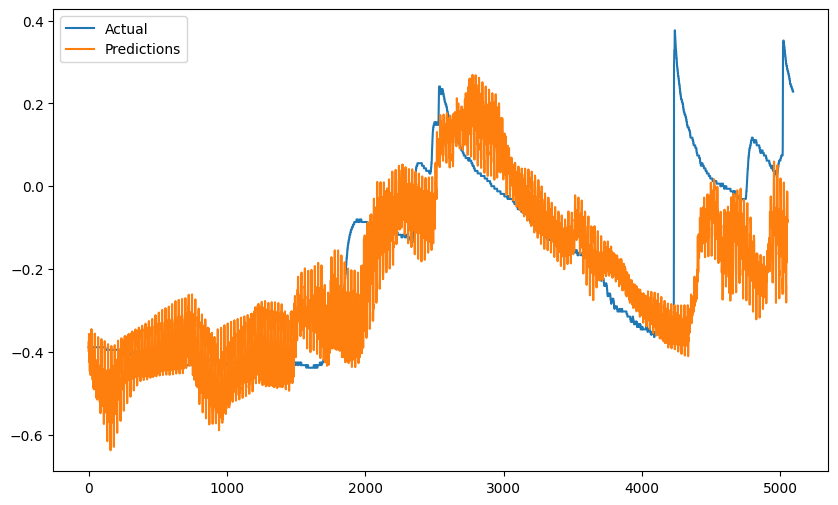

In [ ]:
plot_single_pred(msd_model, test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

79/79 [==============================] - 0s 2ms/step
asd


{'Predictions': array([-0.27377707, -0.2903814 , -0.3116692 , ..., -0.00248976,
         0.00980507,  0.00938417], dtype=float32),
 'Actual': array([-0.38888889, -0.38888889, -0.38888889, ...,  0.22839506,
         0.22839506,  0.22839506])}

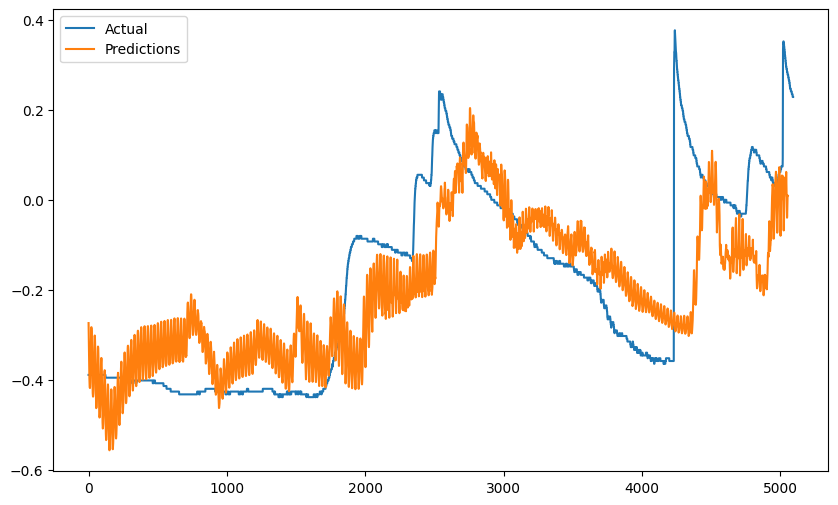

In [ ]:
plot_single_pred(cnn_model, test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

79/79 [==============================] - 1s 7ms/step


{'Predictions': array([-0.46419597, -0.46373686, -0.46357554, ..., -0.03412239,
        -0.02814755, -0.02097567], dtype=float32),
 'Actual': array([-0.38888889, -0.38888889, -0.38888889, ...,  0.22839506,
         0.22839506,  0.22839506])}

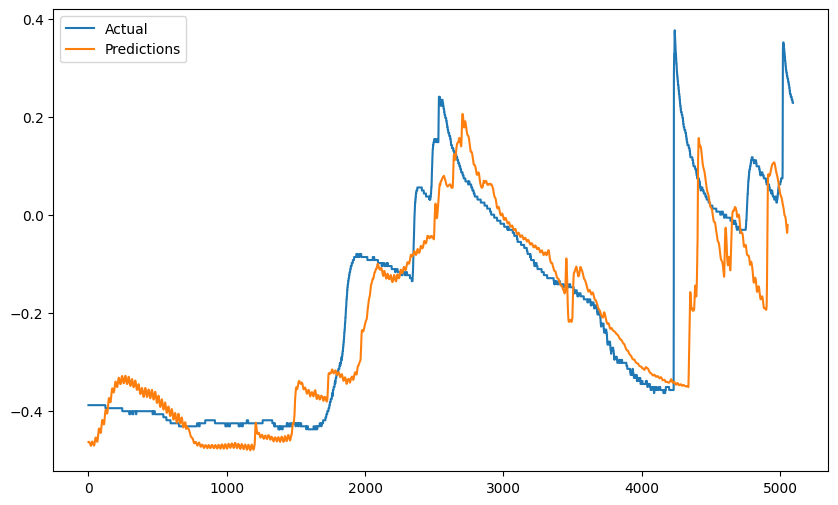

In [ ]:
plot_single_pred(lstm_model, test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

### AutoRegressive RNN

In [ ]:
class FeedBack(tf.keras.Model):
    def __init__(self, units, out_steps, num_features):
        super().__init__()
        self.out_steps = out_steps
        self.units = units
        self.lstm_cell = tf.keras.layers.LSTMCell(units)
        self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
        self.dense = tf.keras.layers.Dense(num_features)

    def call(self, inputs, training=None):
        # Use a TensorArray to capture dynamically unrolled outputs.
        predictions = []

        # Initialize the LSTM state.
        x, *state = self.lstm_rnn(inputs)

        # This is the prediction for the first time step
        prediction = self.dense(x)

        # Insert the first prediction.
        predictions.append(prediction)

        # Run the rest of the prediction steps.
        for n in range(1, self.out_steps):
            # Use the last prediction as input.
            x = prediction
            # Execute one lstm step.
            x, state = self.lstm_cell(x, states=state,
                              training=training)
            # Convert the lstm output to a prediction.
            prediction = self.dense(x)
            # Add the prediction to the output.
            predictions.append(prediction)

        # predictions.shape => (time, batch, features)
        predictions = tf.stack(predictions)
        # predictions.shape => (batch, time, features)
        predictions = tf.transpose(predictions, [1, 0, 2])
        return predictions

In [ ]:
feedback_model = FeedBack(units=64, out_steps=1, num_features=1)

history = compile_and_fit(feedback_model, train_dataset, train_steps, val_dataset, val_steps, model_name=f"ar_rnn/_{TARGET_COL}")
loss_by_epoch["AR RNN"] = history.history
val_performance["AR RNN"] = feedback_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["AR RNN"] = feedback_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/100
595/595 [==============================] - 68s 111ms/step - loss: 0.0228 - mean_absolute_error: 0.1076 - mean_squared_error: 0.0228 - val_loss: 0.0252 - val_mean_absolute_error: 0.1119 - val_mean_squared_error: 0.0252
Epoch 2/100
595/595 [==============================] - 66s 111ms/step - loss: 0.0170 - mean_absolute_error: 0.0854 - mean_squared_error: 0.0170 - val_loss: 0.0209 - val_mean_absolute_error: 0.1026 - val_mean_squared_error: 0.0209
Epoch 3/100
595/595 [==============================] - 67s 112ms/step - loss: 0.0161 - mean_absolute_error: 0.0812 - mean_squared_error: 0.0161 - val_loss: 0.0191 - val_mean_absolute_error: 0.0988 - val_mean_squared_error: 0.0191
Epoch 4/100
595/595 [==============================] - 66s 112ms/step - loss: 0.0158 - mean_absolute_error: 0.0798 - mean_squared_error: 0.0158 - val_loss: 0.0181 - val_mean_absolute_error: 0.0961 - val_mean_squared_error: 0.0181
Epoch 5/100
595/595 [==============================] - 68s 114ms/step - loss: 0.

In [ ]:
performance["AR RNN"][1]

0.07058240473270416

79/79 [==============================] - 3s 35ms/step
asd


{'Predictions': array([-0.39095083, -0.38826028, -0.38565856, ..., -0.08785895,
        -0.08137265, -0.07607677], dtype=float32),
 'Actual': array([-0.38888889, -0.38888889, -0.38888889, ...,  0.22839506,
         0.22839506,  0.22839506])}

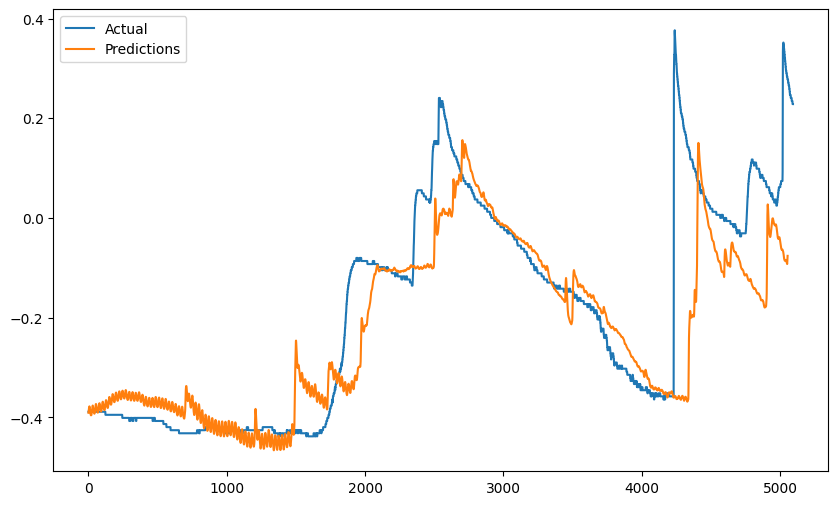

In [ ]:
plot_single_pred(feedback_model, test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

### Evaluation

In [ ]:
loss_by_epoch

{'MSD': {'loss': [0.10405484586954117,
   0.051515623927116394,
   0.02933034487068653,
   0.02556890994310379,
   0.026679733768105507,
   0.027493687346577644,
   0.0284861009567976,
   0.02561272121965885,
   0.02377113327383995,
   0.02026253379881382,
   0.022815633565187454,
   0.023150760680437088,
   0.019581176340579987,
   0.018127944320440292,
   0.017967864871025085,
   0.017324363812804222,
   0.018172580748796463,
   0.01978282444179058,
   0.01643826812505722,
   0.01587962731719017,
   0.01576763205230236,
   0.015917930752038956,
   0.015837259590625763,
   0.01527430396527052,
   0.01542888954281807,
   0.015001657418906689,
   0.015166854485869408,
   0.014773189090192318,
   0.014811903238296509,
   0.014496564865112305,
   0.014376497827470303,
   0.01399320363998413,
   0.014028189703822136],
  'mean_absolute_error': [0.2259451448917389,
   0.16954126954078674,
   0.12655550241470337,
   0.1150677427649498,
   0.11639806628227234,
   0.11941898614168167,
   0.1166

In [ ]:
val_performance

{'MSD': [0.01790357381105423, 0.08857844024896622, 0.01790357381105423],
 'CNN': [0.018071437254548073, 0.10803486406803131, 0.018071437254548073],
 'RNN': [0.010481489822268486, 0.058578912168741226, 0.010481489822268486],
 'AR RNN': [0.011432255618274212, 0.06612977385520935, 0.011432255618274212]}

In [ ]:
performance

{'MSD': [0.022316494956612587, 0.10331510007381439, 0.022316494956612587],
 'CNN': [0.02102912776172161, 0.11018138378858566, 0.02102912776172161],
 'RNN': [0.014314529486000538, 0.06959134340286255, 0.014314529486000538],
 'AR RNN': [0.01570931449532509, 0.07058240473270416, 0.01570931449532509]}

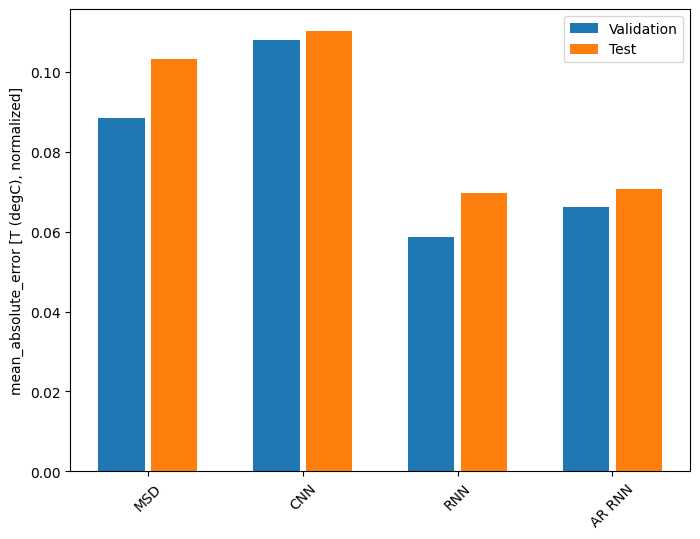

In [ ]:
x = np.arange(len(performance))
width = 0.3
metric_name = 'mean_absolute_error'
metric_index = lstm_model.metrics_names.index('mean_absolute_error')
val_mae = [v[metric_index] for v in val_performance.values()]
test_mae = [v[metric_index] for v in performance.values()]

plt.ylabel('mean_absolute_error [T (degC), normalized]')
plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=performance.keys(),
           rotation=45)
_ = plt.legend()

In [ ]:
msd_pred = msd_model.predict(test_dataset, batch_size=BATCH_SIZE, steps=test_steps)[:, 0, 0]
cnn_pred = cnn_model.predict(test_dataset, batch_size=BATCH_SIZE, steps=test_steps)[:, 0, 0]
rnn_pred = lstm_model.predict(test_dataset, batch_size=BATCH_SIZE, steps=test_steps)[:, 0]
ar_rnn_pred = feedback_model.predict(test_dataset, batch_size=BATCH_SIZE, steps=test_steps)[:, 0, 0]

79/79 [==============================] - 3s 36ms/step


In [ ]:
#Store Results CSV:

import csv
%cd /content/drive/My Drive/Results/NoMET

fields = ["MODEL_NAME","TARGET COL","WINDOW_SIZE"," SHIFT_AMT", "MAX_EPOCHS","MAE", "VAL_MAE","LOSS_BY_EPOCH", "Lables", "Predictions"]

msd_row = ["MSD",TARGET_COL, WINDOW_SIZE, SHIFT_AMT, MAX_EPOCHS, performance["MSD"][1], val_performance["MSD"][1], loss_by_epoch["MSD"], y_test, msd_pred ]

cnn_row = ["CNN",TARGET_COL, WINDOW_SIZE, SHIFT_AMT, MAX_EPOCHS, performance["CNN"][1], val_performance["CNN"][1], loss_by_epoch["CNN"], y_test, cnn_pred]

lstm_row = ["RNN", TARGET_COL, WINDOW_SIZE, SHIFT_AMT, MAX_EPOCHS, performance["RNN"][1], val_performance["RNN"][1], loss_by_epoch["RNN"], y_test, rnn_pred]

ar_rnn_row = ["AR RNN", TARGET_COL, WINDOW_SIZE, SHIFT_AMT, MAX_EPOCHS, performance["AR RNN"][1], val_performance["AR RNN"][1], loss_by_epoch["AR RNN"], y_test, ar_rnn_pred]

#change flag to append
with open('MSD_results.csv', 'a') as file:
    writer = csv.writer(file)
    #writer.writerow(fields)
    writer.writerow(msd_row)
    file.close()

with open('CNN_results.csv', 'a') as file:
    writer = csv.writer(file)
    #writer.writerow(fields)
    writer.writerow(cnn_row)
    file.close()

with open('RNN_results.csv', 'a') as file:
    writer = csv.writer(file)
    #writer.writerow(fields)
    writer.writerow(lstm_row)
    file.close()

with open('AR_RNN_results.csv', 'a') as file:
    writer = csv.writer(file)
    #writer.writerow(fields)
    writer.writerow(ar_rnn_row)
    file.close()

/content/drive/My Drive/Results/NoMET


In [ ]:
def plot_error_by_epoch(error_by_epoch, model_name):
    plot_data = {"Train": error_by_epoch[model_name]["loss"],
                 "Validation":error_by_epoch[model_name]["val_loss"]}
    plt.figure(figsize=(10, 6))
    plt.plot(plot_data["Train"])
    plt.plot(plot_data["Validation"])
    plt.legend(("Train","Validation"))
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss by Epoch")
    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

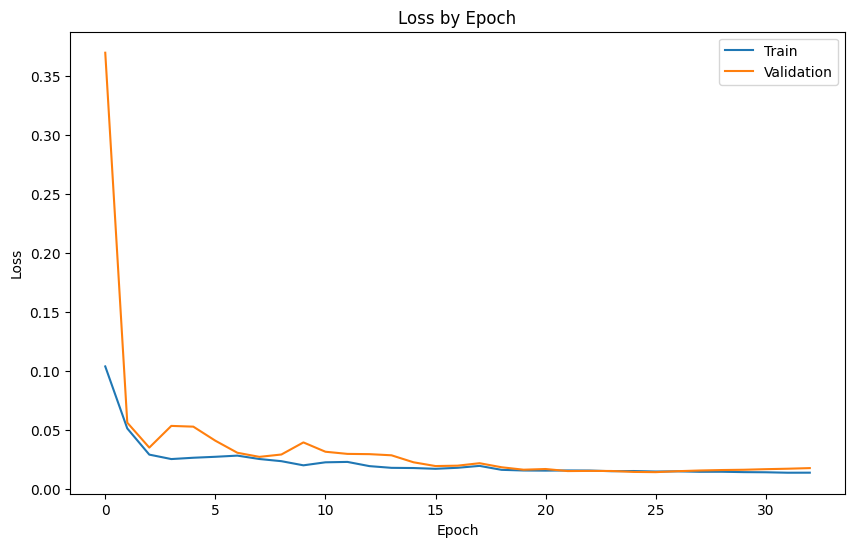

In [ ]:
plot_error_by_epoch(loss_by_epoch, "MSD")

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

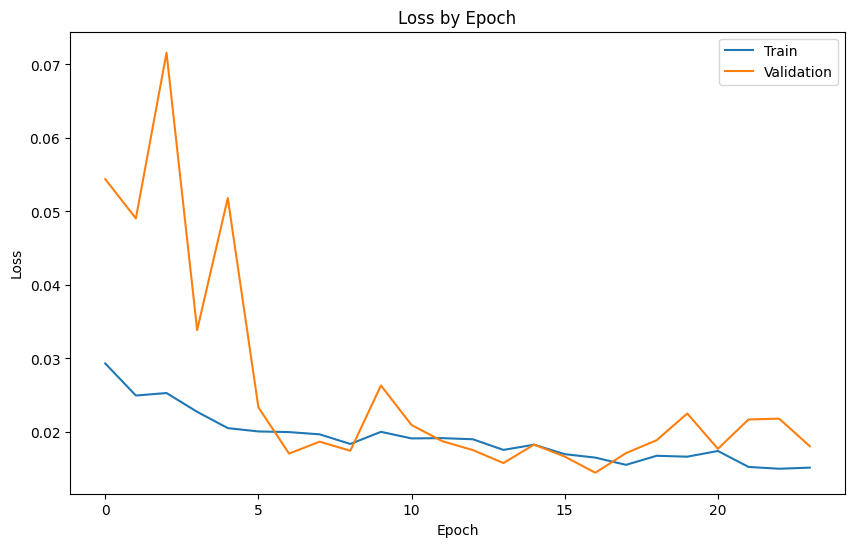

In [ ]:
plot_error_by_epoch(loss_by_epoch, "CNN")

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

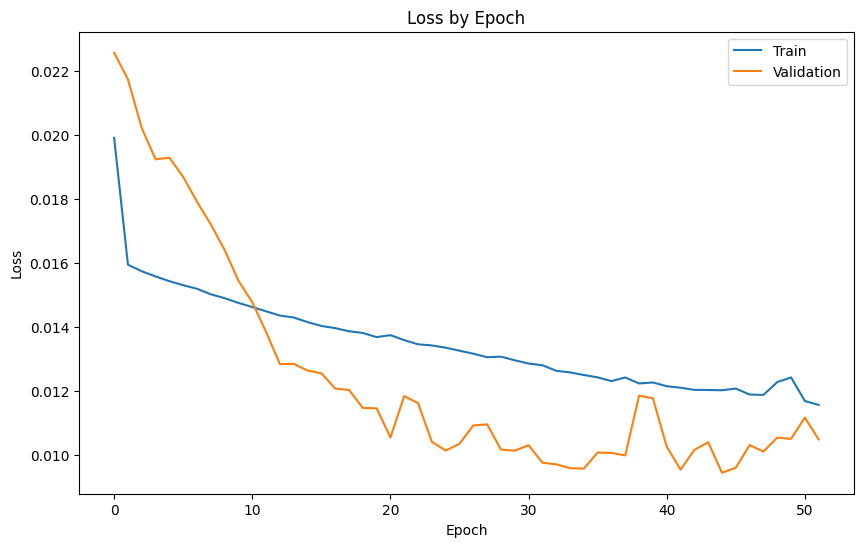

In [ ]:
plot_error_by_epoch(loss_by_epoch, "RNN")

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

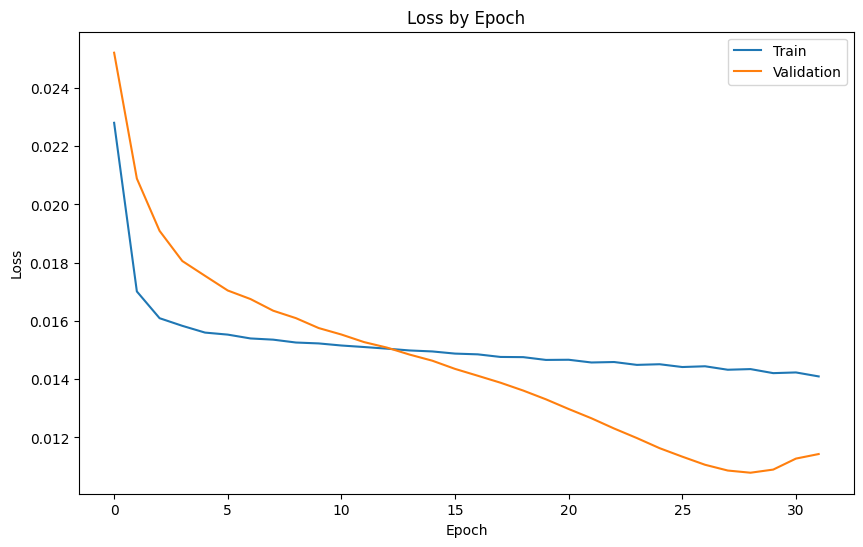

In [ ]:
plot_error_by_epoch(loss_by_epoch, "AR RNN")